In [1]:
from statsbombpy import sb
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from mplsoccer import Pitch, Sbopen

Plot the cumulative xG progression plots for both teams in a match

In [6]:
# Given a match
match_id = 3930162
events = sb.events(match_id)
lineups = sb.lineups(match_id)
home_team = list(lineups.keys())[0]
away_team = list(lineups.keys())[1]

In [54]:
# Player nickname
home_players = lineups[home_team][['player_name', 'player_nickname']]
away_players = lineups[away_team][['player_name', 'player_nickname']]
home_players['nickname'] = home_players['player_nickname'].fillna(home_players['player_name'])
away_players['nickname'] = away_players['player_nickname'].fillna(away_players['player_name'])
# Player nickname for display
def player_name_split(player_name):
    if isinstance(player_name, str):
        name_parts = player_name.split()
        if len(name_parts) == 1:
            return "", name_parts[0]
        elif len(name_parts) == 2:
            return name_parts[0], name_parts[1]
        else:
            return name_parts[0], " ".join(name_parts[1:])
    else:
        return "Unknown", "Unknown"
home_players[['first_name', 'last_name']] = home_players['nickname'].apply(player_name_split).tolist()
away_players[['first_name', 'last_name']] = away_players['nickname'].apply(player_name_split).tolist()

/tmp/ipykernel_454318/2630106499.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home_players['nickname'] = home_players['player_nickname'].fillna(home_players['player_name'])
/tmp/ipykernel_454318/2630106499.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  away_players['nickname'] = away_players['player_nickname'].fillna(away_players['player_name'])
/tmp/ipykernel_454318/2630106499.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

Denmark 1 - 1 Slovenia
xG: Denmark 1.51 - 0.97 Slovenia
Shots: Denmark 16 - 11 Slovenia


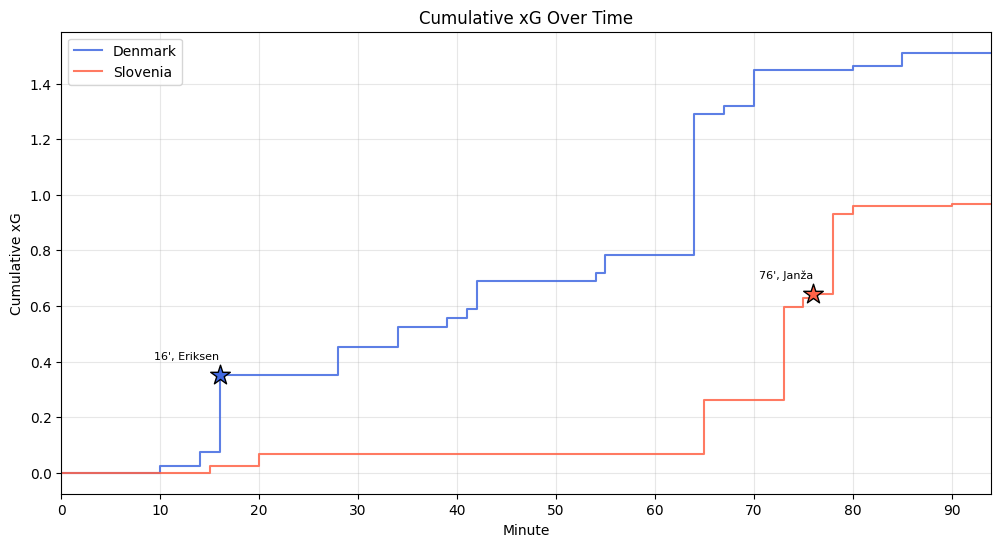

In [61]:
# Find all shots and sort chronologically
shots = events.query("type == 'Shot'").copy()
shots = shots.sort_values(['minute', 'second', 'index'])

# Build team shot tables
team_shots = {
    home_team: shots[shots['team'] == home_team].copy(),
    away_team: shots[shots['team'] == away_team].copy()
}

for team in team_shots:
    team_shots[team]['cumulative_xg'] = team_shots[team]['shot_statsbomb_xg'].cumsum()

# Match summary
home_goal = team_shots[home_team][team_shots[home_team]['shot_outcome'] == 'Goal'].shape[0]
away_goal = team_shots[away_team][team_shots[away_team]['shot_outcome'] == 'Goal'].shape[0]
print(f"{home_team} {home_goal} - {away_goal} {away_team}")
print(f"xG: {home_team} {team_shots[home_team]['shot_statsbomb_xg'].sum():.2f} - {team_shots[away_team]['shot_statsbomb_xg'].sum():.2f} {away_team}")
print(f"Shots: {home_team} {len(team_shots[home_team])} - {len(team_shots[away_team])} {away_team}")

# Player name lookup tables (already prepared in previous cells)
home_lastname = home_players.set_index('player_name')['last_name'].to_dict()
away_lastname = away_players.set_index('player_name')['last_name'].to_dict()
name_lookup = {home_team: home_lastname, away_team: away_lastname}

def format_player_label(player_val, lookup):
    if isinstance(player_val, dict):
        full_name = player_val.get('name', 'Unknown')
    else:
        full_name = str(player_val)
    return lookup.get(full_name, full_name.split()[-1] if full_name else "Unknown")

# Plot
plt.figure(figsize=(12, 6))
match_duration = events['minute'].max()
for team in (home_team, away_team):
    df_team = team_shots[team]
    color = 'royalblue' if team == home_team else 'tomato'

    # Step curve from 0 to match end
    x = [0] + df_team['minute'].tolist() + [int(match_duration)]
    y = [0] + df_team['cumulative_xg'].tolist()
    y.append(y[-1] if y else 0)

    plt.step(x, y, where='post', label=team, alpha=0.85, color=color)

    # Goal markers + labels
    goals = df_team[df_team['shot_outcome'] == 'Goal']
    for _, goal in goals.iterrows():
        gx = int(goal['minute'])
        gy = goal['cumulative_xg']
        player_label = format_player_label(goal['player'], name_lookup[team])

        plt.scatter(gx, gy, color=color, marker='*', s=220, edgecolor='black', zorder=5)
        plt.text(gx, gy + 0.05, f"{gx}', {player_label}", ha='right', va='bottom', fontsize=8)

plt.xlim(0, int(match_duration))
plt.xticks(np.arange(0, int(match_duration) + 1, 10))
plt.title('Cumulative xG Over Time')
plt.xlabel('Minute')
plt.ylabel('Cumulative xG')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [64]:
# Calculate exact goal-count probabilities from shot-level xG (independent Bernoulli trials)
home_xg_values = team_shots[home_team]['shot_statsbomb_xg'].tolist()
away_xg_values = team_shots[away_team]['shot_statsbomb_xg'].tolist()

def goal_pmf(xg_values):
    # pmf[g] = P(score exactly g goals)
    pmf = np.array([1.0])
    for p in xg_values:
        new_pmf = np.zeros(len(pmf) + 1)
        new_pmf[:-1] += pmf * (1 - p)  # miss
        new_pmf[1:]  += pmf * p        # goal
        pmf = new_pmf
    return pmf

home_pmf = goal_pmf(home_xg_values)
away_pmf = goal_pmf(away_xg_values)

# Print 0..9 and include 10+ so displayed probabilities sum to 1
max_k = 9
for team_name, pmf in [(home_team, home_pmf), (away_team, away_pmf)]:
    for k in range(0, min(max_k, len(pmf) - 1) + 1):
        print(f"Probability of {team_name} scoring {k} goals: {pmf[k]:.2%}")
    if len(pmf) - 1 > max_k:
        print(f"Probability of {team_name} scoring {max_k + 1}+ goals: {pmf[max_k + 1:].sum():.2%}")
    print(f"Total probability ({team_name}): {pmf.sum():.6f}\n")

Probability of Denmark scoring 0 goals: 17.62%
Probability of Denmark scoring 1 goals: 36.04%
Probability of Denmark scoring 2 goals: 29.15%
Probability of Denmark scoring 3 goals: 12.86%
Probability of Denmark scoring 4 goals: 3.56%
Probability of Denmark scoring 5 goals: 0.67%
Probability of Denmark scoring 6 goals: 0.09%
Probability of Denmark scoring 7 goals: 0.01%
Probability of Denmark scoring 8 goals: 0.00%
Probability of Denmark scoring 9 goals: 0.00%
Probability of Denmark scoring 10+ goals: 0.00%
Total probability (Denmark): 1.000000

Probability of Slovenia scoring 0 goals: 33.68%
Probability of Slovenia scoring 1 goals: 41.75%
Probability of Slovenia scoring 2 goals: 19.47%
Probability of Slovenia scoring 3 goals: 4.49%
Probability of Slovenia scoring 4 goals: 0.56%
Probability of Slovenia scoring 5 goals: 0.04%
Probability of Slovenia scoring 6 goals: 0.00%
Probability of Slovenia scoring 7 goals: 0.00%
Probability of Slovenia scoring 8 goals: 0.00%
Probability of Slovenia

In [66]:
# Probability of home win, draw, away win
home_win_prob = sum(
    home_pmf[i] * away_pmf[:min(i, len(away_pmf))].sum()
    for i in range(len(home_pmf))
)
draw_prob = sum(
    home_pmf[i] * away_pmf[i]
    for i in range(min(len(home_pmf), len(away_pmf)))
)
away_win_prob = sum(away_pmf[j] * sum(home_pmf[i] for i in range(j)) for j in range(len(away_pmf)))
print(f"Probability of {home_team} win: {home_win_prob:.2%}")
print(f"Probability of draw: {draw_prob:.2%}")
print(f"Probability of {away_team} win: {away_win_prob:.2%}")

Probability of Denmark win: 50.64%
Probability of draw: 27.25%
Probability of Slovenia win: 22.11%
